<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/GPU_Accelerated_Hartree_Fock_with_KWANT_CuPy_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

# Kwant + CuPy: self-consistent Hartree–Fock band heatmaps

Select **Runtime → Change runtime type → GPU** in Google Colab. Run the first installation cell once and wait for the automatic restart. Then run the second installation cell and simulation cell. Do not repeatedly run the first cell. The dependency solver installs Kwant and a matched CUDA 12 CuPy environment from conda-forge. Installation requires network access and may take several minutes.

## Physical primer

Nearest-neighbor hopping $t$ delocalizes electrons, while the onsite repulsion $U$ penalizes double occupation. This example uses a two-site magnetic unit cell, permits opposite collinear spin polarizations on its two sites, and determines the occupations self-consistently:

$$H=-t\sum_{\langle ij\rangle,\sigma}(c^\dagger_{i\sigma}c_{j\sigma}+\mathrm{h.c.})+U\sum_i(n_{i\uparrow}-1/2)(n_{i\downarrow}-1/2).$$

The resulting single-particle onsite potential is

$$V_{i\sigma}=U(\langle n_{i\bar\sigma}\rangle-1/2).$$

This is collinear unrestricted Hartree–Fock within a two-site periodic ansatz. The transverse Fock terms vanish because transverse spin coherence is excluded; no nonlocal exchange or long-range Coulomb terms are included. The occupation update uses normalized Bloch eigenvectors and Fermi–Dirac occupations. Particle-hole symmetry fixes the half-filled chemical potential at zero in this centered convention. Changing filling requires a separate chemical-potential solve.

Kwant builds CPU Bloch Hamiltonians, which are transferred to CuPy once. CuPy performs batched diagonalization, occupation updates, and spectral broadening. Kwant itself is not converted into a GPU solver. This tiny model illustrates the interface; GPU overhead may exceed any speed benefit.

The heatmap displays a Lorentzian-broadened density of single-particle states at each momentum:

$$A(q,E)=\frac14\sum_{\sigma,b}\frac{\eta/\pi}{(E-\epsilon_{\sigma b}(q))^2+\eta^2}.$$

It integrates to one over the full energy axis at each momentum. The finite plot window excludes Lorentzian tails. Here $q=2ka$ is the phase across the doubled cell, and $a$ is the physical nearest-neighbor spacing. Both plots use the same folded Brillouin zone and color scale. Broadening $\eta$ is a visualization parameter, not a calculated scattering lifetime; $k_B T/t$ controls the occupations.

## Interpretation and limits

At the default $U/t=3$, the seeded antiferromagnetic mean field converges to opposite sublattice polarizations and produces a gap. The total spin polarization is zero. This broken-symmetry mean-field state is not evidence for finite-temperature long-range magnetic order in an exact one-dimensional chain, and its gap is not an exact many-body Mott-gap calculation. An SCF fixed point alone does not establish the lowest-free-energy state among other magnetic or charge patterns.

The code checks Hermiticity, noninteracting analytic bands, half filling, sublattice symmetry, SCF residual, and the analytic gap relation for this ansatz. Dense diagonalization is intentional for 2 × 2 spin blocks; a sparse eigensolver returning only a few states would omit occupied states needed for this density update.

## Control knobs

| Parameter | Default | Meaning |
|---|---:|---|
| `U_OVER_T` | 3 | Onsite repulsion relative to hopping |
| `KBT_OVER_T` | 0.02 | Occupation-smearing temperature in hopping units |
| `N_K` | 512 | Uniform momentum sampling, with no duplicated endpoint |
| `ETA_OVER_T` | 0.04 | Lorentzian heatmap width |
| `MIXING` | 0.35 | Fraction of newly computed density in each step |
| `TOLERANCE` | 1e-9 | Maximum unmixed density residual |
| `INITIAL_POLARIZATION` | 0.2 | Symmetry-breaking seed, not imposed final polarization |
| `USE_GPU` | True | CuPy GPU execution; False selects NumPy reference mode |

## Documentation

- [Kwant wraparound](https://kwant-project.org/doc/latest/reference/kwant.wraparound)
- [CuPy batched Hermitian diagonalization](https://docs.cupy.dev/en/stable/reference/generated/cupy.linalg.eigh.html)
- [Mean-field Hubbard formulation](https://dipc-cc.github.io/hubbard/docs/latest/index.html)
- [CondaColab installation and restart](https://github.com/conda-incubator/condacolab)
- [CuPy installation](https://docs.cupy.dev/en/stable/install.html)

In [ ]:
"""This script initializes Conda in the Colab environment."""

!pip install -q condacolab
import condacolab
condacolab.install()

"""This script installs the target scientific libraries via Conda and uv."""

# Control Knobs
CONDA_PACKAGES = [
    "kwant",
    "numpy",
    "scipy",
    "matplotlib"
]

PIP_PACKAGES = [
    "tinyarray>=1.2.4",
    "cupy-cuda12x"
]

!conda install -y -q -c conda-forge {" ".join(CONDA_PACKAGES)}
!python -m pip -q install uv
!uv pip install --system {" ".join(PIP_PACKAGES)}

GPU: b'Tesla T4'
Converged in 100 iterations; residual = 9.279e-10
n_up(A,B) = [0.81030534 0.18969466]; n_down(A,B) = [0.18969466 0.81030534]
Sublattice polarization = [ 0.62061068 -0.62061068]; HF gap/t = 1.861832
SCF elapsed: 3.46 s


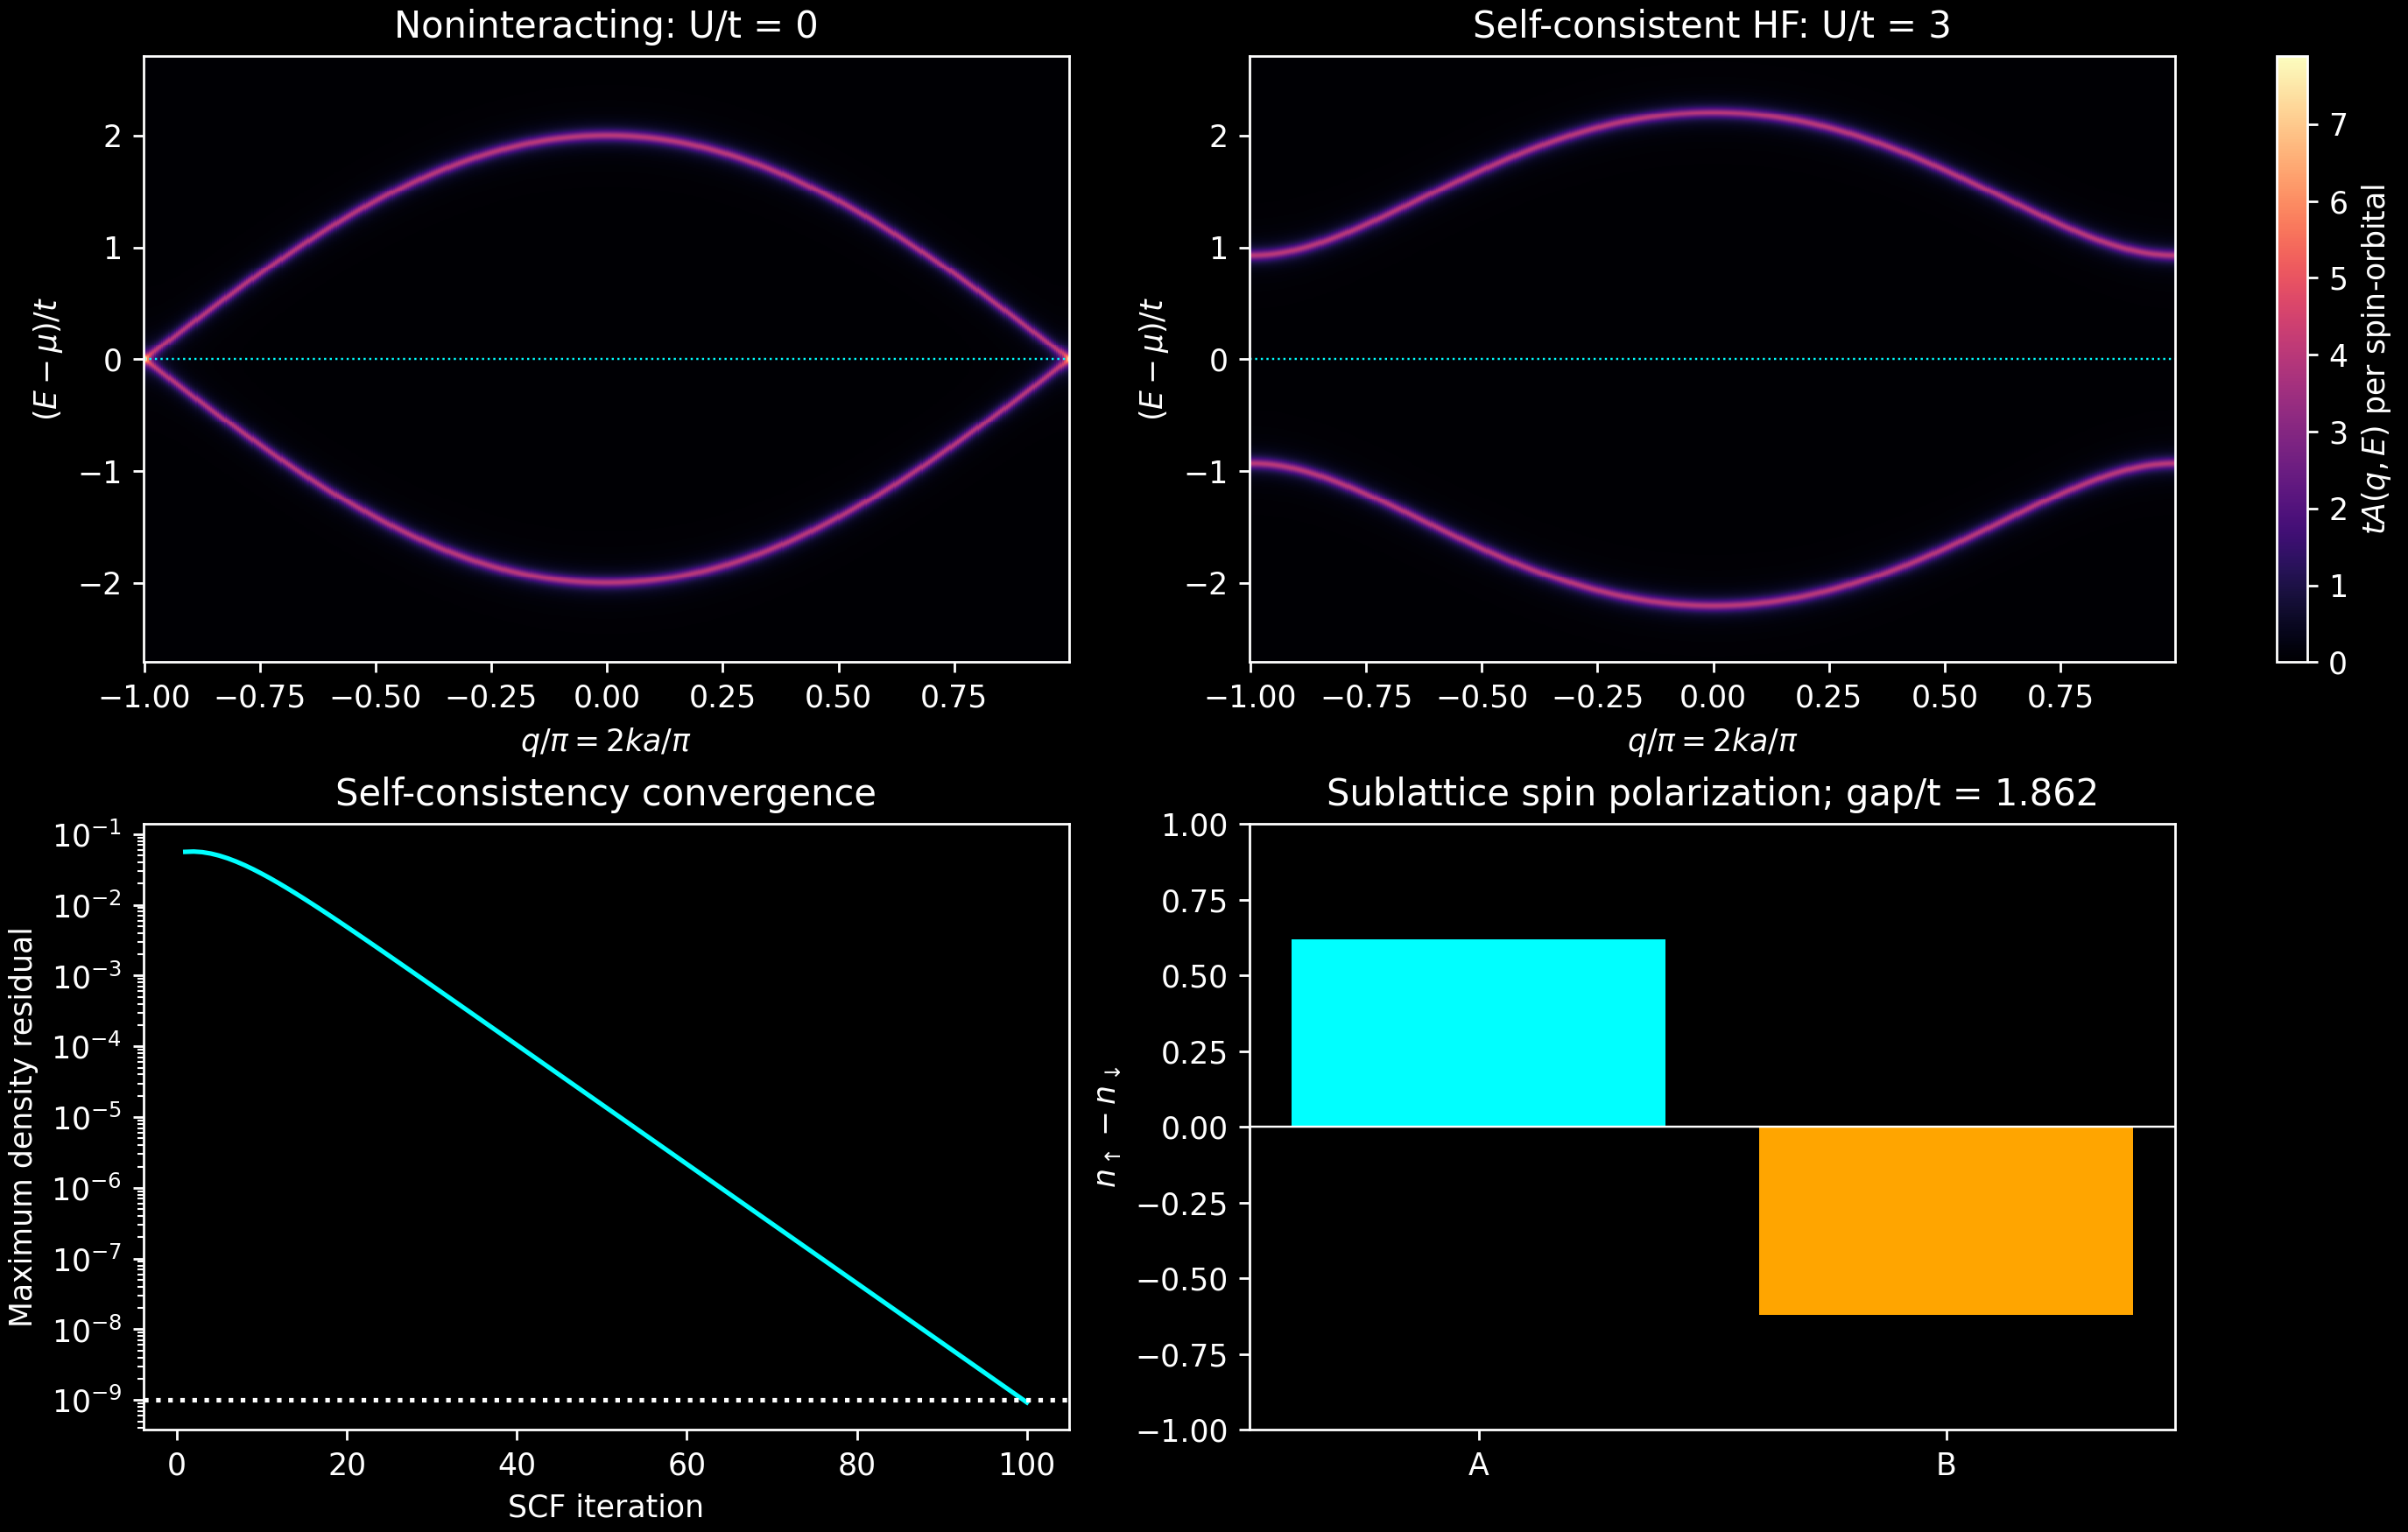

In [1]:
"""Plot self-consistent Hubbard Hartree–Fock bands using Kwant and CuPy.

The two-site magnetic cell describes a half-filled nearest-neighbor chain.
Collinear spin order is allowed; transverse spin coherence is excluded.
Plots are rendered in memory at 250 DPI. Energies are in units of t.
"""

# - Control knobs -
U_OVER_T = 3.0
KBT_OVER_T = 0.02
N_K = 512
N_ENERGY = 700
ETA_OVER_T = 0.04
MIXING = 0.35
TOLERANCE = 1e-9
MAX_ITERATIONS = 1500
INITIAL_POLARIZATION = 0.2
USE_GPU = True
DPI = 250

import io
import time

import kwant
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, display
from kwant.wraparound import wraparound

if USE_GPU:
    import cupy as xp
    if xp.cuda.runtime.getDeviceCount() < 1:
        raise RuntimeError("Select a Colab GPU runtime, or set USE_GPU=False.")
    print("GPU:", xp.cuda.runtime.getDeviceProperties(0)["name"])
else:
    xp = np
    print("CPU reference mode")

assert U_OVER_T >= 0 and KBT_OVER_T > 0
assert ETA_OVER_T > 0 and 0 < MIXING <= 1
assert N_K >= 32 and N_K % 2 == 0
assert 0 < INITIAL_POLARIZATION < 1
plt.style.use("dark_background")
plt.rcParams.update({"figure.dpi": DPI, "savefig.dpi": DPI})


def host(array):
    """Return a NumPy array for plotting or validation."""
    return xp.asnumpy(array) if USE_GPU else np.asarray(array)


# - Kwant CPU construction; q = k times the two-site cell length -
lattice = kwant.lattice.chain(norbs=1)
builder = kwant.Builder(kwant.TranslationalSymmetry((2,)))
builder[lattice(0)] = 0.0
builder[lattice(1)] = 0.0
builder[lattice(0), lattice(1)] = -1.0
builder[lattice(1), lattice(2)] = -1.0
system = wraparound(builder).finalized()
q = np.linspace(-np.pi, np.pi, N_K, endpoint=False)
h0_cpu = np.stack([
    system.hamiltonian_submatrix(params={"k_x": float(momentum)})
    for momentum in q
])
assert np.allclose(h0_cpu, h0_cpu.conj().transpose(0, 2, 1))
expected_bands = np.stack((-2 * np.abs(np.cos(q / 2)),
                           2 * np.abs(np.cos(q / 2))), axis=-1)
np.testing.assert_allclose(np.linalg.eigvalsh(h0_cpu), expected_bands,
                           atol=1e-12)
h0 = xp.asarray(h0_cpu)
indices = xp.arange(2)


def solve(density, interaction):
    """Diagonalize both spin blocks and return the density fixed-point map.

    Particle-hole centering subtracts U/2 from each onsite potential.
    At half filling in this symmetric antiferromagnetic sector, mu = 0.
    Arrays use spin, momentum, site, and eigenstate axes as applicable.
    """
    potential = interaction * (density[::-1] - 0.5)
    hamiltonian = xp.broadcast_to(h0, (2, N_K, 2, 2)).copy()
    hamiltonian[:, :, indices, indices] += potential[:, None, :]
    eigenvalues, eigenvectors = xp.linalg.eigh(hamiltonian)
    occupation = 1 / (1 + xp.exp(xp.clip(
        eigenvalues / KBT_OVER_T, -700, 700)))
    new_density = xp.einsum(
        "skib,skb->si", xp.abs(eigenvectors) ** 2, occupation) / N_K
    return eigenvalues, new_density


# - Self-consistency: residual is measured before density mixing -
start = time.perf_counter()
seed = INITIAL_POLARIZATION / 2
n = xp.asarray([[0.5 + seed, 0.5 - seed],
                [0.5 - seed, 0.5 + seed]])
residuals = []
for iteration in range(MAX_ITERATIONS):
    bands, n_out = solve(n, U_OVER_T)
    residual = float(xp.max(xp.abs(n_out - n)).item())
    residuals.append(residual)
    if residual < TOLERANCE:
        break
    n = (1 - MIXING) * n + MIXING * n_out
else:
    raise RuntimeError(
        f"SCF did not converge: residual={residual:.3e}. "
        "Reduce MIXING or increase MAX_ITERATIONS.")

bands, n_out = solve(n, U_OVER_T)
bands_free, _ = solve(xp.full((2, 2), 0.5), 0.0)
n_cpu = host(n)
np.testing.assert_allclose(n_cpu.sum(axis=0), 1.0, atol=1e-7)
np.testing.assert_allclose(n_cpu[0], n_cpu[1, ::-1], atol=1e-7)
polarization = n_cpu[0] - n_cpu[1]
gap = 2 * float(xp.min(xp.abs(bands)).item())
np.testing.assert_allclose(gap, U_OVER_T * abs(polarization[0]),
                           atol=1e-7)
print(f"Converged in {len(residuals)} iterations; "
      f"residual = {residuals[-1]:.3e}")
print(f"n_up(A,B) = {n_cpu[0]}; n_down(A,B) = {n_cpu[1]}")
print(f"Sublattice polarization = {polarization}; HF gap/t = {gap:.6f}")
print(f"SCF elapsed: {time.perf_counter() - start:.2f} s")

# - Lorentzian spectral heatmaps, normalized per spin-orbital -
limit = max(2.5, float(xp.max(xp.abs(bands)).item()) + 0.5)
energy = xp.linspace(-limit, limit, N_ENERGY)


def spectral_map(eigenvalues):
    """Return A(q,E), averaging over four spin-orbital states per cell."""
    spectrum = xp.zeros((N_ENERGY, N_K), dtype=xp.float64)
    for spin in range(2):
        for band in range(2):
            offset = energy[:, None] - eigenvalues[spin, :, band][None, :]
            spectrum += ETA_OVER_T / (
                xp.pi * (offset ** 2 + ETA_OVER_T ** 2)) / 4
    return host(spectrum)


spectra = [spectral_map(bands_free), spectral_map(bands)]
vmax = max(spectrum.max() for spectrum in spectra)
fig, axes = plt.subplots(2, 2, figsize=(11, 7), layout="constrained")
for axis, spectrum, title in zip(
        axes[0], spectra, ["Noninteracting: U/t = 0",
                          f"Self-consistent HF: U/t = {U_OVER_T:g}"]):
    mesh = axis.pcolormesh(q / np.pi, host(energy), spectrum,
                           shading="auto", cmap="magma", vmin=0, vmax=vmax)
    axis.axhline(0, color="cyan", linewidth=0.7, linestyle=":")
    axis.set(xlabel=r"$q/\pi = 2ka/\pi$", ylabel=r"$(E-\mu)/t$",
             title=title)
fig.colorbar(mesh, ax=axes[0].tolist(), label=r"$t A(q,E)$ per spin-orbital")
axes[1, 0].semilogy(np.arange(1, len(residuals) + 1), residuals,
                    color="cyan")
axes[1, 0].axhline(TOLERANCE, color="white", linestyle=":")
axes[1, 0].set(xlabel="SCF iteration", ylabel="Maximum density residual",
               title="Self-consistency convergence")
axes[1, 1].bar(["A", "B"], polarization, color=["cyan", "orange"])
axes[1, 1].axhline(0, color="white", linewidth=0.7)
axes[1, 1].set(ylabel=r"$n_\uparrow-n_\downarrow$",
               title=f"Sublattice spin polarization; gap/t = {gap:.3f}",
               ylim=(-1, 1))
figure_buffer = io.BytesIO()
fig.savefig(figure_buffer, format="png", dpi=DPI, facecolor=fig.get_facecolor())
plt.close(fig)
display(Image(data=figure_buffer.getvalue()))